In [1]:
%load_ext autoreload
%autoreload 2


# helper functions

## Sampling random densities for X

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, dirichlet

 

 


def reflect(value, lower, upper):
    """Reflects a value within the given bounds [lower, upper]."""
    range_size = upper - lower
    while value < lower or value > upper:
        if value < lower:
            value = lower + (lower - value)  # Reflect off the lower bound
        elif value > upper:
            value = upper - (value - upper)  # Reflect off the upper bound
    return value

import numpy as np
from scipy.stats import beta

def sample_random_walk_beta_params(K, min_ab=0.7, max_ab=10.0, step_size=0.1, seed=None):
    """
    Generates K (a, b) pairs for Beta distributions using a random walk 
    with reflection to stay within bounds.

    Parameters:
        K : int
            Number of Beta distributions to sample.
        min_ab : float
            Minimum value for Beta parameters.
        max_ab : float
            Maximum value for Beta parameters.
        step_size : float
            Standard deviation of the random walk step (controls similarity).
        seed : int, optional
            Random seed for reproducibility.

    Returns:
        a_params, b_params : np.ndarray, np.ndarray
            Arrays of shape (K,) containing sampled Beta parameters.
    """
    rng = np.random.default_rng(seed)
    
    a_params = np.zeros(K)
    b_params = np.zeros(K)

    a_params[0] = rng.uniform(min_ab, max_ab)
    b_params[0] = rng.uniform(min_ab, max_ab)

    for i in range(1, K):
        a_new = a_params[i-1] + rng.normal(scale=step_size)
        b_new = b_params[i-1] + rng.normal(scale=step_size)

        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params
 
 


 


import numpy as np
from scipy.special import gamma

def beta_pdf(x, a, b):
    """
    Compute the Beta density at x given parameters a and b.
    
    Parameters:
        x : float or np.ndarray
            The point(s) at which to evaluate the density (should lie in [0,1]).
        a : float
            The first shape parameter.
        b : float
            The second shape parameter.
    
    Returns:
        float or np.ndarray: The beta density evaluated at x.
    """
    return (gamma(a + b) / (gamma(a) * gamma(b))) * (np.power(x, a - 1)) * (np.power(1 - x, b - 1))

 
 
import numpy as np
from scipy.stats import beta
 

def compute_conditional_and_marginal_density(x, a_params, b_params, U_levels, U_probs):
    """
    Computes the conditional density functions f(x|Z=z) for each group Z,
    and the overall marginal density f(x), for the model:
    
        X = Beta(a, b) + U,
    
    where U is a discrete confounder with levels U_levels and probabilities U_probs.
    
    For a given group with Beta parameters (a, b), the density at x is:
    
         f(x|Z=z) = sum_{u in U_levels} beta.pdf(x - u; a, b) * P(U=u)
    
    The marginal density is computed as the (equally weighted) average over groups.
    
    Parameters:
        x         : float or array_like
                    Points at which to evaluate the density.
        a_params  : array_like, shape (K,)
                    Group-level Beta distribution alpha parameters.
        b_params  : array_like, shape (K,)
                    Group-level Beta distribution beta parameters.
        U_levels  : array_like, shape (M,)
                    The discrete levels for U.
        U_probs   : array_like, shape (M,)
                    The probability mass for each U level (should sum to 1).
                    
    Returns:
        conditional_density : np.ndarray, shape (len(x), K)
            The conditional density f(x|Z=z) for each group z.
        marginal_density    : np.ndarray, shape (len(x),)
            The marginal density f(x), computed as the average over groups.
    """
    # Ensure x is a 1D array.
    x = np.atleast_1d(x)
    n = len(x)
    
    # Ensure a_params and b_params are arrays of shape (K,)
    a_params = np.atleast_1d(a_params)
    b_params = np.atleast_1d(b_params)
    K = len(a_params)
    
    # Convert U_levels and U_probs to arrays and ensure U_levels has shape (M,)
    U_levels = np.asarray(U_levels)
    U_probs = np.asarray(U_probs)
    M = len(U_levels)
    
    # Expand dimensions for vectorized evaluation:
    #   x_expanded: shape (n, 1, 1)
    #   U_expanded: shape (1, M, 1)
    #   a_params and b_params: shape (1, 1, K)
    x_expanded = x[:, None, None]
    U_expanded = U_levels[None, :, None]
    a_expanded = a_params[None, None, :]
    b_expanded = b_params[None, None, :]
    
    # Evaluate the Beta density at (x - u) for each combination of x, u, and group.
    # This returns an array of shape (n, M, K)
    pdf_vals = beta.pdf(x_expanded - U_expanded, a_expanded, b_expanded)
    
    # Incorporate the probability mass of each U level.
    # Reshape U_probs to (1, M, 1) so it broadcasts correctly.
    U_probs_expanded = U_probs[None, :, None]
    
    # Sum over the discrete U levels (axis=1) to get the conditional density for each group.
    # Resulting shape is (n, K)
    conditional_density = np.sum(pdf_vals * U_probs_expanded, axis=1)
    
    # Compute the marginal density as the average over groups.
    marginal_density = np.mean(conditional_density, axis=1)
    
    return conditional_density, marginal_density

# === Example Usage ===
if True:
    # Assume we have K groups and the discrete confounder U with M levels.
    K = 5
    M = 10
    n_points = 100  # number of x values at which to evaluate the density
    
    # Example group-level Beta parameters (each > 0).
    a_params = np.linspace(2, 5, K)  # e.g., group 1 has a=2, group 5 has a=5
    b_params = np.linspace(3, 6, K)  # similarly for b parameters
    
    # Define U_levels as in your discrete_gaussian over [0, 1].
    U_levels = np.linspace(0, 1, M)
    # Recompute the probabilities for U using a discrete Gaussian weight.
    mu_U = 0.5
    sigma_U = 0.3
    weights = np.exp(-0.5 * ((U_levels - mu_U) / sigma_U)**2)
    U_probs = weights / np.sum(weights)
    
    # Evaluate density on a grid of x values.
    # X is generated as Beta(a, b) + U, so x can lie roughly in [0, 2]
    x_values = np.linspace(0, 2, n_points)
    
    cond_density, marg_density = compute_conditional_and_marginal_density(
        x_values, a_params, b_params, U_levels, U_probs
    )
    
    print("Conditional density shape (x vs groups):", cond_density.shape)
    print("Marginal density shape (x):", marg_density.shape)

print(len(a_params), len(x_values))

Conditional density shape (x vs groups): (100, 5)
Marginal density shape (x): (100,)
5 100


## Generate HAL basis for Ridge Regression

In [102]:
import numpy as np
import matplotlib.pyplot as plt


def generate_basis_functions(epsilon=0.05, J=None, L=1):
    """
    Generates step function basis functions x -> 1(x > t) with knots in [0,1].
    If J is not provided, it is determined by ensuring an L-Lipschitz function 
    can be approximated within error epsilon.

    Parameters:
        epsilon : float, optional (default=0.05)
            The maximum allowable approximation error for an L-Lipschitz function.
        J : int, optional
            The number of basis functions (knots). If None, it is computed from epsilon.
        L : float, optional (default=1)
            The Lipschitz constant of the function to approximate.

    Returns:
        knots : np.array, shape (J,)
            The knot points in [0,1].
    """
    # Compute J if not given
    if J is None:
        J = max(1,int(np.ceil(L / (2 * epsilon))))

    # Create J equally spaced knot points in (0,1)
    knots = np.linspace(0, 1, J + 2)[:-1]  # Avoid endpoints 0 and 1    
 
    return knots

def construct_design_matrix(X, knots):
    """
    Constructs a design matrix for the step function basis on input X.

    Parameters:
        X : np.array, shape (N,)
            Input data points.
        knots : np.array, shape (J,)
            Knot points for the basis functions.

    Returns:
        design_matrix : np.array, shape (N, J)
            The design matrix where each column corresponds to 1(X > t_j).
    """
    return (X[:, None] > knots).astype(float)
 

# Generate data

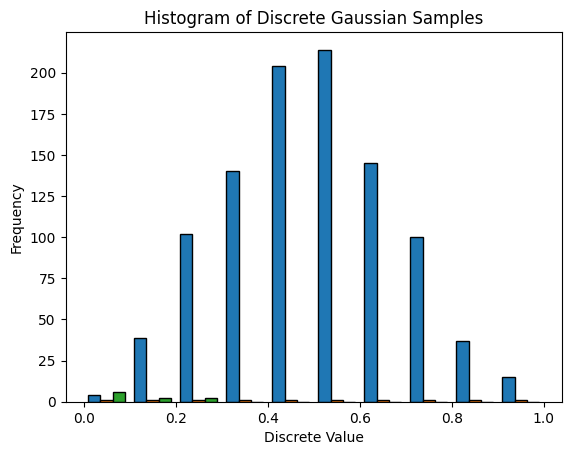

In [103]:
import numpy as np

def discrete_gaussian(N, M, mu=0, sigma=0.1, lower=-1, upper=1, rng=None):
    """
    Samples N values from a discrete set of M evenly spaced points in [lower, upper],
    weighted according to a Gaussian distribution with mean mu and standard deviation sigma.
    
    Parameters:
      N (int): Number of samples to generate.
      M (int): Number of discrete levels in the interval.
      mu (float): Mean of the Gaussian weighting.
      sigma (float): Standard deviation of the Gaussian weighting.
      lower (float): Lower bound of the interval.
      upper (float): Upper bound of the interval.
      rng (np.random.Generator, optional): Numpy random number generator instance.
      
    Returns:
      np.ndarray: Array of N samples drawn from the discrete distribution.
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # Create M evenly spaced levels in [lower, upper]
    U_levels = np.linspace(lower, upper, M)
    
    # Compute unnormalized weights from the Gaussian density (ignoring the normalization constant)
    weights = np.exp(-0.5 * ((U_levels - mu) / sigma) ** 2)
    
    # Normalize weights to obtain probabilities
    probs = weights / np.sum(weights)
    
    # Sample N points from U_levels with the computed probabilities
    return rng.choice(U_levels, size=N, p=probs), U_levels, probs

# Example usage:
rng = np.random.default_rng(42)
samples = discrete_gaussian(N=1000, M=10, mu=0.5, sigma=0.2, lower=0, upper=1)
# Plotting the histogram
plt.hist(samples, bins=np.linspace(0, 1, 11), edgecolor='black')
plt.xlabel('Discrete Value')
plt.ylabel('Frequency')
plt.title('Histogram of Discrete Gaussian Samples')
plt.show()


In [104]:
import numpy as np
from scipy.stats import beta

 
def generate_data(K=1000, n=10, M=10, n_new=100_000, pZ_effect=0.1, range_ab=(0.75, 5), ab_new=None, step_size=0.1, delta=0.2, h_fun=None, seed_exps=None, seed_new = None, return_density=True):
    """
    Generates data based on the given simulation structure.

    Parameters:
        K         : int  - Number of groups (instrument levels, experiments).
        n         : int  - Number of samples per group.
        M         : int  - Number of levels for confounder U.
        range_ab  : tuple - Range for beta parameters (min, max).
        step_size : float - Step size for random walk beta parameter generation.
        delta     : float - Confounding effect parameter.
        h_fun     : function - Structural function for Y. Defaults to sin(6x).
        seed_exps : int - Random seed for generating a_params and b_params.

    Returns:
        dict : Keys {X, Y, Z, U, a_params, b_params, density_X_given_Z, h_fun}
               containing generated data and density function.
    """
    rng = np.random.default_rng()  # Fresh RNG instance for other random variables
    N = K * n  # Total sample size
    if h_fun is None:
        h_fun = lambda x: (6*x)  + np.sin(6 * x)

    # Generate U and Z
    sigma_U = 0.2
    U, U_levels, U_probs = discrete_gaussian(N=N, M=M, mu=0, sigma=sigma_U, lower=-0.5, upper=0.5, rng = rng)
    Z = np.repeat(np.arange(K), n)

    # Generate a_params and b_params with fixed seed
    a_params_effect, b_params_effect = sample_random_walk_beta_params(
        int(pZ_effect * K), min_ab=range_ab[0], max_ab=range_ab[1], step_size=step_size, seed=seed_exps
    )

    # Expand a_params and b_params
    repeats = K // len(a_params_effect)
    extra = K % len(a_params_effect)
    repeat_counts = np.full(len(a_params_effect), repeats)
    repeat_counts[:extra] += 1
    a_params = np.repeat(a_params_effect, repeat_counts)
    b_params = np.repeat(b_params_effect, repeat_counts)

    X = beta.rvs(a_params[Z], b_params[Z], random_state=rng) + U
    eps = rng.normal(0, 0.3, size=N)
    Y = h_fun(X) +   2 * U + eps

    #print(np.corrcoef(U, X)[0, 1])
    #print(np.corrcoef(U, Y)[0, 1])
    #print(np.array([np.corrcoef(Z == k, X)[0, 1] for k in range(K)]))
    #print(np.array([np.corrcoef(Z == k, Y)[0, 1] for k in range(K)]))

 

    # Generate new data
    U_new, U_levels_new, U_probs_new = discrete_gaussian(N=n_new, M=M, mu=0, sigma=sigma_U, lower=-0.5, upper=0.5, rng = rng)
    if ab_new is None:
        a_param_new, b_param_new = sample_random_walk_beta_params(1, range_ab[0], range_ab[1], step_size, seed_new)
    else:
        a_param_new, b_param_new = ab_new
    X_new = beta.rvs(a_param_new, b_param_new,  size=n_new, random_state=rng) + U_new


    density_new = lambda x: compute_conditional_and_marginal_density(x, a_param_new, b_param_new, U_levels_new, U_probs_new)[0]


    #print(np.corrcoef(U_new, X_new)[0, 1])
    #print(np.corrcoef(U_new, Y_new)[0, 1])
    
    #print(np.corrcoef(U_new, h_fun(X_new))[0, 1])
 
    
    if return_density:
        density_X_given_Z = lambda x: compute_conditional_and_marginal_density(x, a_params, b_params, U_levels, U_probs)[0]
    else:
        density_X_given_Z = None

    return {
        "X": X,
        "Y": Y,
        "Z": Z,
        "U": U,
        "eps": eps,
        "X_new": X_new,
        "a_params": a_params,
        "b_params": b_params,
        "density_X_given_Z": density_X_given_Z,
        "density_new": density_new,
        "h_fun": h_fun,
        "K": K,
        "M": M,
        "delta": delta
    }


In [105]:
# Example usage:
h_fun = lambda x: x # Example custom function
n = 1000
K = 1000
M = 10
step_size = 0.1
data = generate_data(h_fun=h_fun, n=n, K=K, M = M, step_size = step_size, pZ_effect = 0.1,   delta = 0.2, n_new = 1000000)
X = data['X']
Z = data['Z']
U = data['U']
eps = data['eps']

print(np.quantile(U, [0.1,0.25, 0.5,0.75, 0.9]))
np.quantile(X, [0.1,0.25, 0.5,0.75, 0.9])

[-0.27777778 -0.16666667 -0.05555556  0.16666667  0.27777778]


array([0.34523415, 0.54227536, 0.74810691, 0.93107312, 1.08455811])

In [107]:
import numpy as np

def compute_bias_factor_cat(X, U, eps, Z, n):
    """
    Computes the bias factor and asymptotic 2SLS bias when Z is categorical.
    
    Instead of using a linear regression, this function computes the group
    means of X for each category of Z to estimate E[X|Z]. Then, it calculates
    the first-stage residuals v = X - E[X|Z], and uses these to compute the bias factor:
    
        bias factor = Cov(v, U+eps) / Var(v),
    
    and the asymptotic bias is (1/n) * bias factor.
    
    Parameters:
        X : array_like
            The generated endogenous variable.
        U : array_like
            The confounder variable.
        eps : array_like
            The error term in the outcome equation.
        Z : array_like
            The categorical instrument variable.
        n : int
            The number of observations per instrument group.
    
    Returns:
        bias_factor : float
            The computed bias factor.
        asymptotic_bias : float
            The asymptotic bias given by (1/n) * bias_factor.
    """
    # Initialize an array for the estimated E[X|Z]
    X_hat = np.empty_like(X)
    
    # Compute group means for each unique category in Z
    unique_categories = np.unique(Z)
    for cat in unique_categories:
        indices = (Z == cat)
        X_hat[indices] = np.mean(X[indices])
    
    # Compute first-stage residuals
    v = X - X_hat
    
    # The true structural error is U + eps
    true_error = 3 * U + eps
    
    # Compute covariance and variance
    cov_v_error = np.cov(v, true_error, ddof=1)[0, 1]
    var_v = np.var(v, ddof=1)
    
    # Compute bias factor and asymptotic bias
    print(var_v, cov_v_error)
    bias_factor = cov_v_error / var_v
    asymptotic_bias = bias_factor / n
    
    return bias_factor, asymptotic_bias

# Example usage:
bias_factor, asymptotic_bias = compute_bias_factor_cat(X, U, eps, Z, n = 30)
print("Bias Factor:", bias_factor)
print("Asymptotic 2SLS Bias:", asymptotic_bias)


0.08061127176169398 0.11518509020858478
Bias Factor: 1.4288955835990182
Asymptotic 2SLS Bias: 0.04762985278663394


# Check asymptotic identification

## Structural parameter

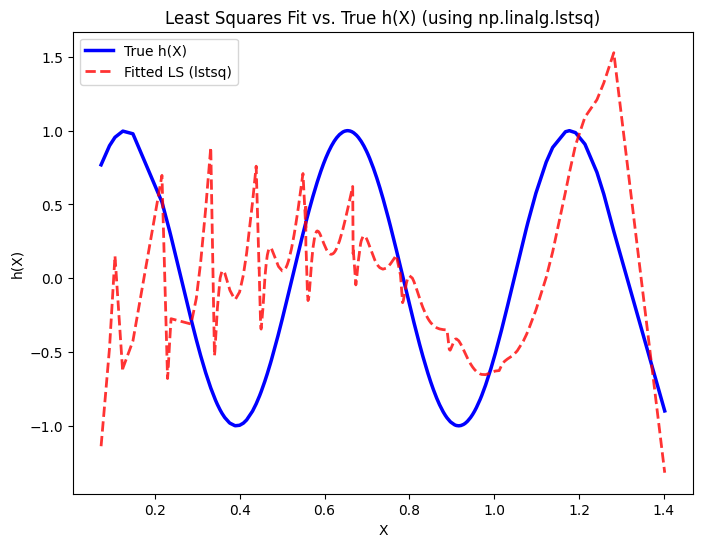

In [136]:
h_fun = lambda x: np.sin(12 * x)  # Example custom function
n = 30
K = 10
M = 10
step_size = 0.05
data = generate_data(h_fun=h_fun, n=n, K=K, M = M, step_size = step_size, pZ_effect = 1)
X = data["X"]
# Compute the true function values
h_X = data["h_fun"](X)  # True values of h(X)

# Compute the density matrix
density_matrix = data["density_X_given_Z"](X)  # Shape: (N, K)
density_matrix_marginal = np.mean(density_matrix, axis = 1)
density_matrix_norm = density_matrix / density_matrix_marginal[:, None]

# Solve least squares problem using np.linalg.lstsq
beta_star, _, _, _ = np.linalg.lstsq(density_matrix_norm, h_X, rcond=None)  # Least-squares solution

# Compute fitted values
h_X_fitted = density_matrix_norm @ beta_star  # Predicted values

# Sort data for smooth plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
h_X_sorted = h_X[sort_idx]
h_X_fitted_sorted = h_X_fitted[sort_idx]

# --- Plotting ---
plt.figure(figsize=(8, 6))

# True function (Solid Blue Line)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='blue', linewidth=2.5)

# Fitted LS function (Dashed Red Line)
plt.plot(X_sorted, h_X_fitted_sorted, label="Fitted LS (lstsq)", linestyle='dashed', color='red', linewidth=2, alpha=0.8)

# Labels & Legend
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Least Squares Fit vs. True h(X) (using np.linalg.lstsq)")
plt.legend()
plt.show()

## Riesz representer

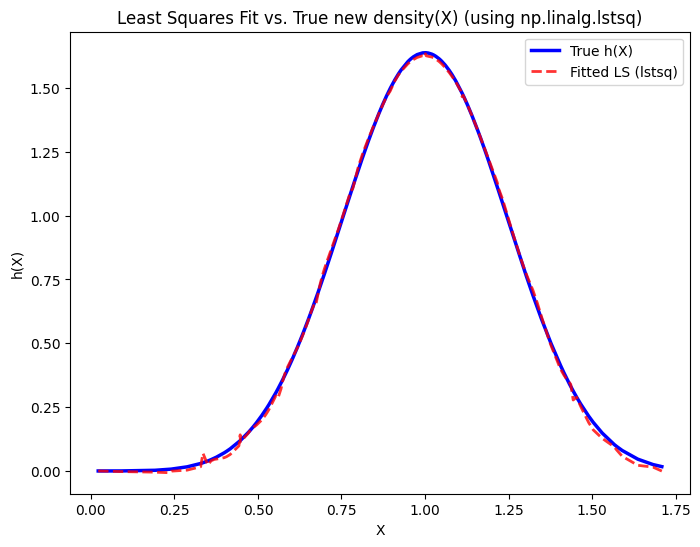

In [137]:
n = 30
K = 10
M = 10
step_size = 0.05
ab_new = [6,6]
data = generate_data(h_fun=h_fun, n=n, K=K, M = M, ab_new = ab_new, step_size = step_size, pZ_effect = 1)
X = data["X"]


 
# Compute the density matrix
density_matrix = data["density_X_given_Z"](X)  # Shape: (N, K)
density_new = data["density_new"](X)  # Shape: (N, 1)

# Solve least squares problem using np.linalg.lstsq
beta_star, _, _, _ = np.linalg.lstsq(density_matrix, density_new, rcond=None)  # Least-squares solution

# Compute fitted values
density_new_fitted = density_matrix @ beta_star  # Predicted values

# Sort data for smooth plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
density_new_sorted = density_new[sort_idx]
density_new_fitted_sorted = density_new_fitted[sort_idx]

# --- Plotting ---
plt.figure(figsize=(8, 6))

# True function (Solid Blue Line)
plt.plot(X_sorted, density_new_sorted, label="True h(X)", color='blue', linewidth=2.5)

# Fitted LS function (Dashed Red Line)
plt.plot(X_sorted, density_new_fitted_sorted, label="Fitted LS (lstsq)", linestyle='dashed', color='red', linewidth=2, alpha=0.8)

# Labels & Legend
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Least Squares Fit vs. True new density(X) (using np.linalg.lstsq)")
plt.legend()
plt.show()

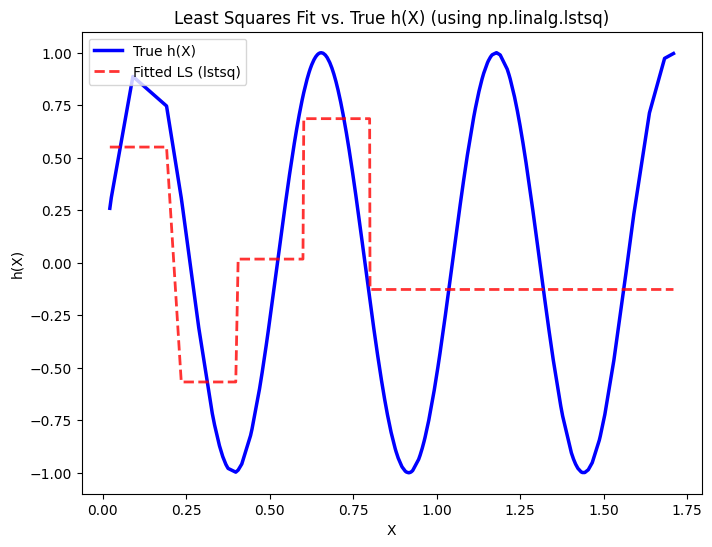

In [138]:
import numpy as np
import matplotlib.pyplot as plt


def generate_basis_functions(epsilon=0.05, J=None, L=1):
    """
    Generates step function basis functions x -> 1(x > t) with knots in [0,1].
    If J is not provided, it is determined by ensuring an L-Lipschitz function 
    can be approximated within error epsilon.

    Parameters:
        epsilon : float, optional (default=0.05)
            The maximum allowable approximation error for an L-Lipschitz function.
        J : int, optional
            The number of basis functions (knots). If None, it is computed from epsilon.
        L : float, optional (default=1)
            The Lipschitz constant of the function to approximate.

    Returns:
        knots : np.array, shape (J,)
            The knot points in [0,1].
    """
    # Compute J if not given
    if J is None:
        J = max(1,int(np.ceil(L / (2 * epsilon))))

    # Create J equally spaced knot points in (0,1)
    knots = np.linspace(0, 1, J + 2)[:-1]  # Avoid endpoints 0 and 1    
 
    return knots

def construct_design_matrix(X, knots):
    """
    Constructs a design matrix for the step function basis on input X.

    Parameters:
        X : np.array, shape (N,)
            Input data points.
        knots : np.array, shape (J,)
            Knot points for the basis functions.

    Returns:
        design_matrix : np.array, shape (N, J)
            The design matrix where each column corresponds to 1(X > t_j).
    """
    return (X[:, None] > knots).astype(float)

# --- Main Execution ---

# Get data
X = data['X']  # Compute the true function values
h_X = data["h_fun"](X)  # True values of h(X)
n = len(X)
# Generate basis functions
knots = generate_basis_functions(n**(-1/3))

# Construct design matrix
X_basis = construct_design_matrix(X, knots)  # FIXED FUNCTION CALL

# Solve least squares problem using np.linalg.lstsq
beta_star, _, _, _ = np.linalg.lstsq(X_basis, h_X, rcond=None) 

# Compute fitted values
h_X_fitted = X_basis @ beta_star  # Predicted values

# Sort data for smooth plotting
sort_idx = np.argsort(X)  # FIXED VARIABLE NAME
X_sorted = X[sort_idx]  # FIXED REFERENCE TO X
h_X_sorted = h_X[sort_idx]
h_X_fitted_sorted = h_X_fitted[sort_idx]

# --- Plotting ---
plt.figure(figsize=(8, 6))

# True function (Solid Blue Line)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='blue', linewidth=2.5)

# Fitted LS function (Dashed Red Line)
plt.plot(X_sorted, h_X_fitted_sorted, label="Fitted LS (lstsq)", linestyle='dashed', color='red', linewidth=2, alpha=0.8)

# Labels & Legend
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Least Squares Fit vs. True h(X) (using np.linalg.lstsq)")
plt.legend()
plt.show()


# Fitting nuisance functions

In [7]:
# settings
freq = 3.14
h_fun = lambda x: x 
L = 3  # Lipschitz constant
n = 100
K = 1000
M = 10
step_size = 0.2

## Fit structural function NPIV

Gamma: 1.00e-01, Lambda: 1.00e-01, Risk: -0.218867, Quad term: 0.016939,  break: 0.000000
Split: -0.218867, Split: -0.219211
inf 0
Gamma: 1.00e-01, Lambda: 4.28e-02, Risk: -0.221777, Quad term: 0.019169,  break: 0.000000
Split: -0.221777, Split: -0.222028
0.0029094025695820813 inf
Gamma: 1.00e-01, Lambda: 1.83e-02, Risk: -0.222674, Quad term: 0.020277,  break: 0.000000
Split: -0.222674, Split: -0.222874
0.000897676060443664 0.0029094025695820813
Gamma: 1.00e-01, Lambda: 7.85e-03, Risk: -0.222974, Quad term: 0.020785,  break: 0.000000
Split: -0.222974, Split: -0.223150
0.00029987494895131195 0.000897676060443664
Gamma: 1.00e-01, Lambda: 3.36e-03, Risk: -0.223085, Quad term: 0.021009,  break: 0.000000
Split: -0.223085, Split: -0.223250
0.00011081764265075122 0.00029987494895131195
Gamma: 1.00e-01, Lambda: 1.44e-03, Risk: -0.223129, Quad term: 0.021106,  break: 0.000000
Split: -0.223129, Split: -0.223289
4.403978732331337e-05 0.00011081764265075122
Gamma: 1.00e-01, Lambda: 6.16e-04, Risk:

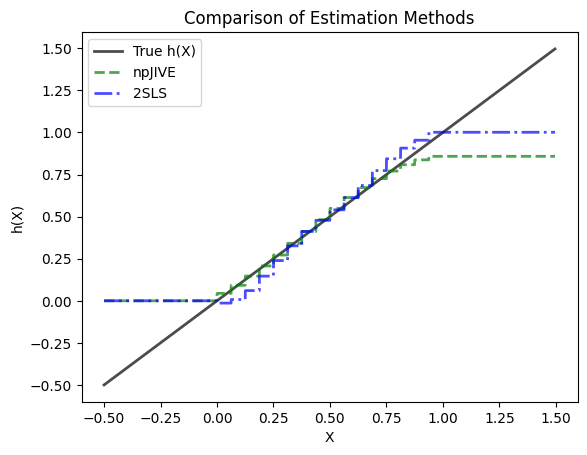

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.utils import *
from discreteNPIV.solve_primal_structural import *
from discreteNPIV.npiv_2SLS import *
from discreteNPIV.solve_primal_npJIVE_original import *



# Generate synthetic data for model fitting and evaluation
data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1)
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)

data_eval = generate_data(h_fun=h_fun, n=500, K=K, M=M, step_size=step_size, pZ_effect=1)
folds_eval = make_cross_folds(data_eval['Z'])

# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=L)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)

# ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
np.random.seed(123)
theta_hat, _, cv_output = npiv_structural(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=True)
params_jive, params_2sls, use_npjiv, cross_folds = cv_output

h_hat_npiv = X_basis @ theta_hat
h_hat_val_npiv = construct_design_matrix(data_eval['X'], knots) @ theta_hat
risk_npiv = np.sqrt(compute_primal_risk(h_hat_val_npiv, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("NPIV Risk:", risk_npiv)

# ---- npJIVE Fit ----
theta_hat_jive, _ = solve_primal_structural(
    X_basis, Z, Y, K, cross_folds=cross_folds,
    lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],num_repeats=10
)
h_hat_jive = X_basis @ theta_hat_jive
h_hat_val_jive = construct_design_matrix(data_eval['X'], knots) @ theta_hat_jive
risk_jive = np.sqrt(compute_primal_risk(h_hat_val_jive, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("npJIVE Risk:", risk_jive)

# ---- 2SLS Fit ----
theta_hat_2sls, h_fun_init = solve_primal_structural_2SLS(
    X_basis, Z, Y, K, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
)
h_hat_2sls = X_basis @ theta_hat_2sls
h_hat_val_2sls = construct_design_matrix(data_eval['X'], knots) @ theta_hat_2sls
risk_2sls = np.sqrt(compute_primal_risk(h_hat_val_2sls, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("2SLS Risk:", risk_2sls)

# ---- Plot all methods together ----
plt.figure()

# Sort X and corresponding values
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
h_X_sorted = h_X[sorted_indices]
h_hat_npiv_sorted = h_hat_npiv[sorted_indices]
h_hat_jive_sorted = h_hat_jive[sorted_indices]
h_hat_2sls_sorted = h_hat_2sls[sorted_indices]

#plt.plot(X_sorted, h_hat_npiv_sorted, label="NPIV Primal", color='red', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='black', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_hat_jive_sorted, label="npJIVE", color='green', alpha=0.7, linewidth=2, linestyle='dashed')
plt.plot(X_sorted, h_hat_2sls_sorted, label="2SLS", color='blue', alpha=0.7, linewidth=2, linestyle='dashdot')

plt.legend()
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Comparison of Estimation Methods")
plt.show()










 



Gamma: 1.00e-01, Lambda: 1.00e-01, Risk: -0.221064, Quad term: 0.017497,  break: 0.000000
Split: -0.221064, Split: -0.221445
inf 0
Gamma: 1.00e-01, Lambda: 4.28e-02, Risk: -0.223941, Quad term: 0.019773,  break: 0.000000
Split: -0.223941, Split: -0.224239
0.002876907015424507 inf
Gamma: 1.00e-01, Lambda: 1.83e-02, Risk: -0.224849, Quad term: 0.020906,  break: 0.000000
Split: -0.224849, Split: -0.225097
0.0009078699410469682 0.002876907015424507
Gamma: 1.00e-01, Lambda: 7.85e-03, Risk: -0.225158, Quad term: 0.021427,  break: 0.000000
Split: -0.225158, Split: -0.225381
0.00030951947895702103 0.0009078699410469682
Gamma: 1.00e-01, Lambda: 3.36e-03, Risk: -0.225274, Quad term: 0.021657,  break: 0.000000
Split: -0.225274, Split: -0.225486
0.00011591480502790019 0.00030951947895702103
Gamma: 1.00e-01, Lambda: 1.44e-03, Risk: -0.225320, Quad term: 0.021757,  break: 0.000000
Split: -0.225320, Split: -0.225527
4.639451717755594e-05 0.00011591480502790019
Gamma: 1.00e-01, Lambda: 6.16e-04, Risk:

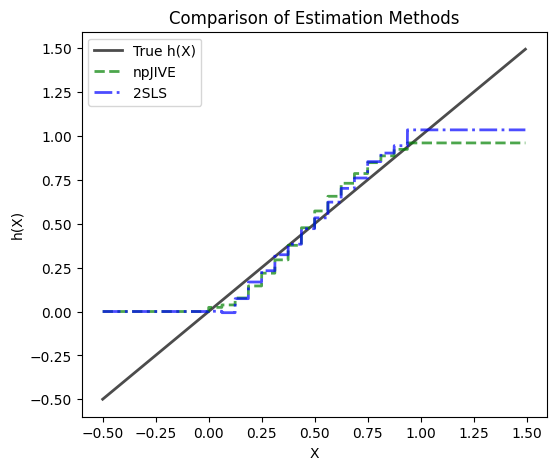

Time to compute fold means: 0.907714 seconds
Time for select tunings: 0.129821 seconds

Selected Parameters and Risks:
----------------------------------------
npJIVE:
  Lambda: 1.00e-08
  Gamma:  7.74e-03
  Risk:   0.00055938
----------------------------------------
2SLS:
  Lambda: 4.83e-05
  Gamma:  5.99e-04
  Risk:   0.00045699
----------------------------------------
Using npJIVE: No
NPIV Risk: 0.008869026310048567
condioning before:  30518965.674954407 -0.00010555813187636814
npJIVE Risk: 0.006803796111154837
2SLS Risk: 0.008869026310048567


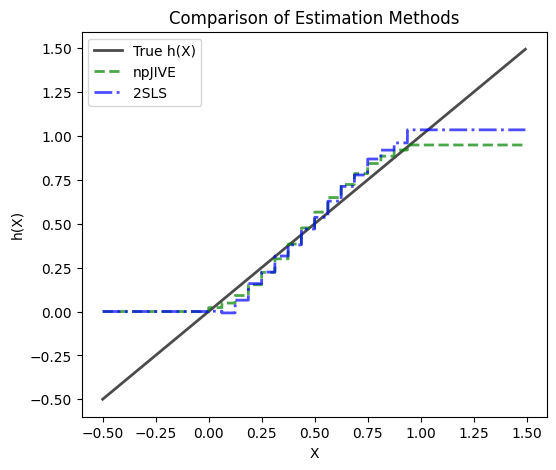

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.utils import *
from discreteNPIV.solve_primal_structural import *
from discreteNPIV.npiv_2SLS import *
from discreteNPIV.solve_primal_npJIVE_original import *



# Generate synthetic data for model fitting and evaluation
data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1)
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)

data_eval = generate_data(h_fun=h_fun, n=500, K=K, M=M, step_size=step_size, pZ_effect=1)
folds_eval = make_cross_folds(data_eval['Z'])

# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=L)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)

# ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
np.random.seed(123)
theta_hat, _, cv_output = npiv_structural(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=True)
params_jive, params_2sls, use_npjiv, cross_folds = cv_output

h_hat_npiv = X_basis @ theta_hat
h_hat_val_npiv = construct_design_matrix(data_eval['X'], knots) @ theta_hat
risk_npiv = np.sqrt(compute_primal_risk(h_hat_val_npiv, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("NPIV Risk:", risk_npiv)

# ---- npJIVE Fit ----
theta_hat_jive, _ = solve_primal_structural(
    X_basis, Z, Y, K, cross_folds=cross_folds,
    lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],num_repeats=10
)
h_hat_jive = X_basis @ theta_hat_jive
h_hat_val_jive = construct_design_matrix(data_eval['X'], knots) @ theta_hat_jive
risk_jive = np.sqrt(compute_primal_risk(h_hat_val_jive, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("npJIVE Risk:", risk_jive)

# ---- 2SLS Fit ----
theta_hat_2sls, h_fun_init = solve_primal_structural_2SLS(
    X_basis, Z, Y, K, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
)
h_hat_2sls = X_basis @ theta_hat_2sls
h_hat_val_2sls = construct_design_matrix(data_eval['X'], knots) @ theta_hat_2sls
risk_2sls = np.sqrt(compute_primal_risk(h_hat_val_2sls, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("2SLS Risk:", risk_2sls)

# ---- Plot all methods together ----
plt.figure(figsize=(6, 5))

# Sort X and corresponding values
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
h_X_sorted = h_X[sorted_indices]
h_hat_npiv_sorted = h_hat_npiv[sorted_indices]
h_hat_jive_sorted = h_hat_jive[sorted_indices]
h_hat_2sls_sorted = h_hat_2sls[sorted_indices]

#plt.plot(X_sorted, h_hat_npiv_sorted, label="NPIV Primal", color='red', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='black', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_hat_jive_sorted, label="npJIVE", color='green', alpha=0.7, linewidth=2, linestyle='dashed')
plt.plot(X_sorted, h_hat_2sls_sorted, label="2SLS", color='blue', alpha=0.7, linewidth=2, linestyle='dashdot')

plt.legend()
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Comparison of Estimation Methods")
plt.show()










 
from discreteNPIV.solve_primal_npJIVE_original import *
 

 
# ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
np.random.seed(123)
theta_hat, _, cv_output = npiv_primal(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=True)
params_jive, params_2sls, use_npjiv, cross_folds = cv_output

h_hat_npiv = X_basis @ theta_hat
h_hat_val_npiv = construct_design_matrix(data_eval['X'], knots) @ theta_hat
risk_npiv = np.sqrt(compute_JIVE_risk(h_hat_val_npiv, data_eval['Z'], _, data_eval['Y'], folds_eval, K))
print("NPIV Risk:", risk_npiv)

# ---- npJIVE Fit ----
theta_hat_jive, _ = solve_primal_npJIVE(
    X_basis, Z, Y, K, cross_folds=cross_folds,
    lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],
    project_PD=False, num_repeats=10
)
h_hat_jive = X_basis @ theta_hat_jive
h_hat_val_jive = construct_design_matrix(data_eval['X'], knots) @ theta_hat_jive
risk_jive = np.sqrt(compute_JIVE_risk(h_hat_val_jive, data_eval['Z'], _, data_eval['Y'], folds_eval, K))
print("npJIVE Risk:", risk_jive)

# ---- 2SLS Fit ----
theta_hat_2sls, h_fun_init = solve_primal_structural_2SLS(
    X_basis, Z, Y, K, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
)
h_hat_2sls = X_basis @ theta_hat_2sls
h_hat_val_2sls = construct_design_matrix(data_eval['X'], knots) @ theta_hat_2sls
risk_2sls = np.sqrt(compute_JIVE_risk(h_hat_val_2sls, data_eval['Z'], _, data_eval['Y'], folds_eval, K))
print("2SLS Risk:", risk_2sls)

# ---- Plot all methods together ----
plt.figure(figsize=(6, 5))

# Sort X and corresponding values
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
h_X_sorted = h_X[sorted_indices]
h_hat_npiv_sorted = h_hat_npiv[sorted_indices]
h_hat_jive_sorted = h_hat_jive[sorted_indices]
h_hat_2sls_sorted = h_hat_2sls[sorted_indices]

#plt.plot(X_sorted, h_hat_npiv_sorted, label="NPIV Primal", color='red', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='black', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_hat_jive_sorted, label="npJIVE", color='green', alpha=0.7, linewidth=2, linestyle='dashed')
plt.plot(X_sorted, h_hat_2sls_sorted, label="2SLS", color='blue', alpha=0.7, linewidth=2, linestyle='dashdot')

plt.legend()
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Comparison of Estimation Methods")
plt.show()



## Fit debiasing nuisance

In [25]:
import numpy as np
import matplotlib.pyplot as plt


def make_T(data, n = 10_000):
    """
    Constructs an operator T that maps a function h_fun to a vector 
    of conditional expectations E[h(X) | Z = k] for each k.

    Parameters:
        data : dict
            Contains 'K', 'M', 'a_params', 'b_params', and 'delta'.

    Returns:
        T_adjoint : function
            Function that takes h_fun (a function) and returns a vector of length K, 
            where each element is E[h(X) | Z = k].
    """
    # Retrieve parameters
  # Large sample for Monte Carlo estimation
    K, M = data['K'], data['M']
    a_params, b_params = data['a_params'], data['b_params'] 

    
    # Generate samples for Monte Carlo estimation
    Z = np.repeat(np.arange(K), n)
    N = K * n
    # Generate individual-level confounder U
    sigma_U = 0.2
    U, U_levels, U_probs = discrete_gaussian(N=N, M=M, mu=0, sigma=sigma_U, lower=-0.5, upper=0.5)
    X = beta.rvs(a_params[Z], b_params[Z], random_state=rng) + U

 

    # Define  T
    def T_(h_fun):
        """
        Given a function h_fun, compute the conditional expectation E[h(X) | Z = k] 
        for each k using Monte Carlo integration.

        Parameters:
            h_fun : function
                A function that takes scalar input x and outputs h(x).

        Returns:
            E_h_given_Z : np.array, shape (K,)
                Estimated conditional expectation E[h(X) | Z = k].
        """
        h_X = h_fun(X)  # Direct function application

        # Vectorized computation of E[h(X) | Z = k] using np.bincount
        sum_hX = np.bincount(Z, weights=h_X, minlength=K)  # Sum of h(X) per group
        count_Z = np.bincount(Z, minlength=K)  # Count of samples per group
        
        # Compute the conditional expectation, handling zero-division
        E_h_given_Z = np.divide(sum_hX, count_Z, where=(count_Z > 0))  # Avoid division by zero
        
        return E_h_given_Z

    return T_



from scipy.interpolate import interp1d
 

def make_T_adjoint(data, n_grid=200, p_Z=None):
    """
    Constructs an adjoint operator T_adjoint that maps a vector q of length K
    to a function T_adjoint(q)(x), which represents the transformed function.

    Parameters:
        data : dict
            Must contain 'density_X_given_Z', which is a function that returns P(X | Z).
        x_grid : array_like, optional
            Grid of x values to evaluate densities. Defaults to 200 points in [0,1].
        p_Z : array_like, optional
            Prior probability of Z (shape (K,)). Defaults to uniform if not provided.

    Returns:
        function: T_adjoint(q), which returns an interpolated function.
    """
    density_X_given_Z = data['density_X_given_Z']
    X = data['X']
    # Compute equally spaced quantiles from 0 to 1
    quantiles = np.linspace(0, 1, n_grid)

    # Generate the grid on the X scale corresponding to these quantiles
    x_grid = np.quantile(X, quantiles)

    P = density_X_given_Z(x_grid)  # Shape: (n, K)
    
    K = P.shape[1]
    if p_Z is None:
        p_Z = np.full(K, 1/K)  # Uniform prior over Z

    # Compute marginal density P(X) = sum_z P(X | Z) P(Z)
    p_marginal = P @ p_Z  # Shape: (n,)

    # Handle division by zero: set 0/0 to 0
    with np.errstate(divide='ignore', invalid='ignore'):
        T_adjoint_matrix = np.where(p_marginal[:, None] != 0, (P * p_Z) / p_marginal[:, None], 0)

    # Define the T_adjoint operator
    def T_adjoint(q):
        """
        Applies the adjoint operator to q (length K), returning an interpolated function.

        Parameters:
            q : array_like, shape (K,)
                A vector of length K.

        Returns:
            function: T_adj_q(x), an interpolated function.
        """
        if q.shape[0] != T_adjoint_matrix.shape[1]:
            raise ValueError(f"q must have length {T_adjoint_matrix.shape[1]}, got {q.shape[0]}.")

        T_adj_q_grid = T_adjoint_matrix @ q  # Shape: (n,)

        return interp1d(x_grid, T_adj_q_grid, kind='linear', fill_value="extrapolate")

    return T_adjoint, T_adjoint_matrix, x_grid, p_marginal


 
import numpy as np
from scipy.stats import gaussian_kde

def estimate_marginal_density(X):
    X = np.array(X).reshape(-1)

    # Use Gaussian KDE with automatic bandwidth selection (Scott's rule by default)
    kde = gaussian_kde(X)  

    # Evaluate the density estimate at the input points
    density_marginal = kde.evaluate(X)

    return density_marginal


 

Gamma: 1.00e-01, Lambda: 1.00e-01, Risk (JIVE): -1.036478, Risk (2SLS): -1.029856, Quad term: 0.073107,  break: 0.000000
Gamma: 1.00e-01, Lambda: 2.64e-02, Risk (JIVE): -1.063438, Risk (2SLS): -1.055395, Quad term: 0.085291,  break: 0.000000
Gamma: 1.00e-01, Lambda: 6.95e-03, Risk (JIVE): -1.069897, Risk (2SLS): -1.061538, Quad term: 0.089153,  break: 0.000000
Gamma: 1.00e-01, Lambda: 1.83e-03, Risk (JIVE): -1.071523, Risk (2SLS): -1.063097, Quad term: 0.090230,  break: 0.000000
Gamma: 1.00e-01, Lambda: 4.83e-04, Risk (JIVE): -1.071945, Risk (2SLS): -1.063503, Quad term: 0.090518,  break: 0.000000
Gamma: 1.00e-01, Lambda: 1.27e-04, Risk (JIVE): -1.072056, Risk (2SLS): -1.063610, Quad term: 0.090595,  break: 0.000000
Gamma: 1.00e-01, Lambda: 3.36e-05, Risk (JIVE): -1.072086, Risk (2SLS): -1.063638, Quad term: 0.090615,  break: 0.000000
Gamma: 1.00e-01, Lambda: 8.86e-06, Risk (JIVE): -1.072093, Risk (2SLS): -1.063645, Quad term: 0.090620,  break: 0.000000
Gamma: 1.00e-01, Lambda: 2.34e-0

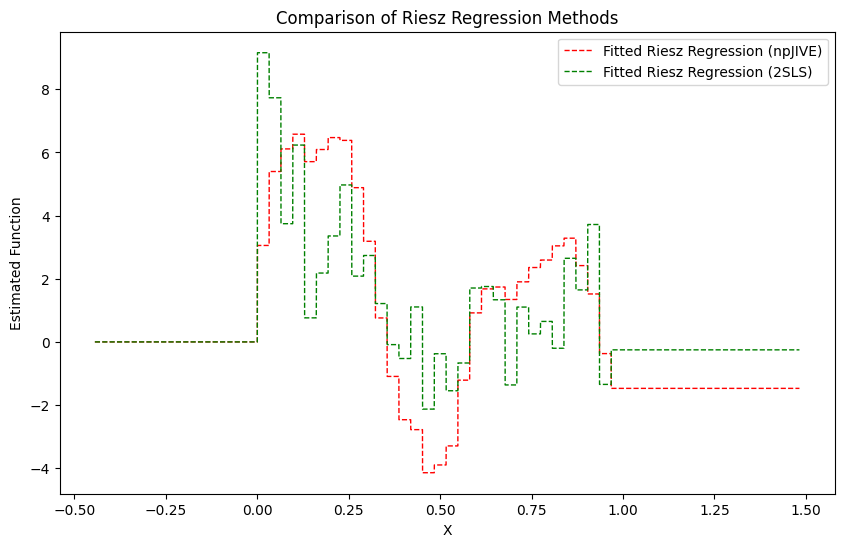

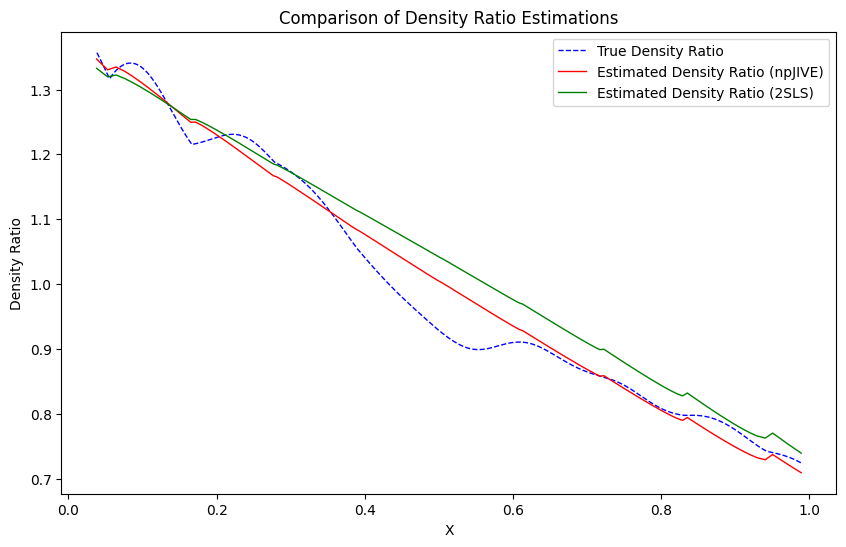

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.solve_dual_riesz import *
from discreteNPIV.npiv_2SLS import *

# Generate synthetic data
n = 30
K = 1000
step_size = 0.5
data = generate_data(h_fun=None, n=n, K=K, M=M, step_size=step_size, pZ_effect=1,  seed_exps=12345, range_ab=(1,8), ab_new=[2, 2.5])
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)

# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=6)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)

# ---- Dual Riesz Estimation (npJIVE) ----
cv_output = cross_validate_dual(
    X_basis, Z, K, X_new_basis, num_lambda=20, num_gamma=20, verbose=True
)
cv_output = params_jive, params_2sls, use_npjiv, cross_folds = cv_output
 

b_hat, _ = solve_dual_riesz(X_basis, Z, K, X_new_basis, lambda_K=params_jive['lambda'], gamma=params_jive['gamma'])

# Define function for predictions
def beta_fun(X):
    X_basis = construct_design_matrix(X, knots)
    return X_basis @ b_hat

 
 

b_hat_2sls, _ = solve_dual_riesz_2SLS(X_basis, Z, K, X_new_basis,  params_2sls['lambda'], gamma=params_2sls['gamma'])

def beta_fun_2sls(X):
    X_basis = construct_design_matrix(X, knots)
    return X_basis @ b_hat_2sls

# ---- Combined Plot: Riesz Regression (npJIVE & 2SLS) ----
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]


plt.figure(figsize=(10, 6))
plt.plot(X_sorted, beta_fun(X_sorted), label="Fitted Riesz Regression (npJIVE)", linestyle='dashed', color='red', linewidth=1)
plt.plot(X_sorted, beta_fun_2sls(X_sorted), label="Fitted Riesz Regression (2SLS)", linestyle='dashed', color='green', linewidth=1)
plt.legend()
plt.xlabel("X")
plt.ylabel("Estimated Function")
plt.title("Comparison of Riesz Regression Methods")
plt.show()
 



# ---- Density Ratio Estimation ----
X_sampled = X[np.random.choice(X.shape[0], 20000, replace=False)]
density_marginal = estimate_marginal_density(X_sampled)
density_new = data["density_new"](X_sampled)
density_ratio = density_new.reshape(-1) / density_marginal.reshape(-1)

# Sort for plotting'


#density_matrix = data["density_X_given_Z"](X)
T_fun = make_T(data)
Tadj_fun, T_adjoint_matrix, x_grid, p_marginal = make_T_adjoint(data)
dr_jive = Tadj_fun(T_fun(beta_fun))(X)
dr_2sls = Tadj_fun(T_fun(beta_fun_2sls))(X)


sort_idx = np.argsort(X_sampled)
X_sorted = X_sampled[sort_idx]
density_ratio_sorted = density_ratio[sort_idx]

sort_idx = np.argsort(X)
X_sorted_full = X[sort_idx]
dr_jive_sorted = dr_jive[sort_idx]
dr_2sls_sorted = dr_2sls[sort_idx]


import numpy as np
import matplotlib.pyplot as plt

# Compute the quantile bounds for X
lower_bound = np.quantile(X, 0.05)
upper_bound = np.quantile(X, 0.95)

# Create a mask for values of X between the quantile bounds
mask = (X_sorted >= lower_bound) & (X_sorted <= upper_bound)

# If your estimated curves use a different array, say X_sorted_full, do the same:
lower_bound_full = np.quantile(X_sorted_full, 0.05)
upper_bound_full = np.quantile(X_sorted_full, 0.95)
mask_full = (X_sorted_full >= lower_bound_full) & (X_sorted_full <= upper_bound_full)

# Now plot only the points within these bounds.
plt.figure(figsize=(10, 6))
plt.plot(X_sorted[mask], density_ratio_sorted[mask], label="True Density Ratio", 
         linestyle='dashed', color='blue', linewidth=1)
plt.plot(X_sorted_full[mask_full], dr_jive_sorted[mask_full], label="Estimated Density Ratio (npJIVE)", 
         linestyle='solid', color='red', linewidth=1)
plt.plot(X_sorted_full[mask_full], dr_2sls_sorted[mask_full], label="Estimated Density Ratio (2SLS)", 
         linestyle='solid', color='green', linewidth=1)
plt.xlabel("X")
plt.ylabel("Density Ratio")
plt.title("Comparison of Density Ratio Estimations")
plt.legend()
plt.show()


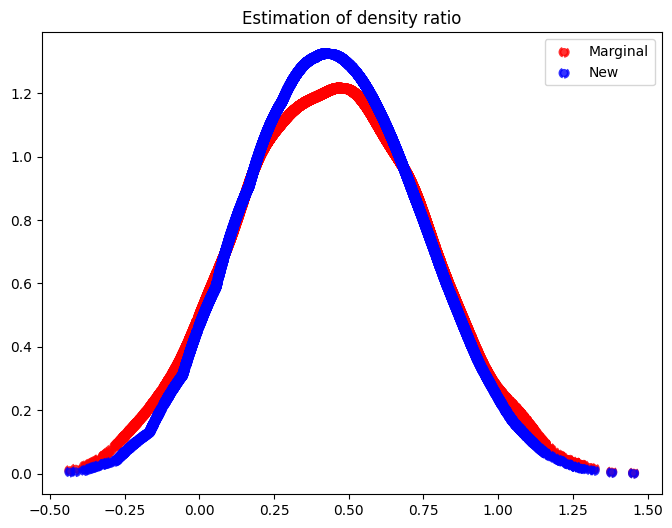

In [81]:
 

X_sampled = X[np.random.choice(X.shape[0], 5000, replace=False)]
density_marginal =  estimate_marginal_density(X_sampled) 
density_new = data["density_new"](X_sampled)
density_ratio = density_new.reshape(-1) / density_marginal.reshape(-1)
sort_idx = np.argsort(X_sampled)
X_sorted = X_sampled[sort_idx]
density_ratio_sorted = density_ratio[sort_idx]

 


plt.figure(figsize=(8, 6))


# Fitted LS function (Dashed Red Line)
plt.scatter(X_sampled,  density_marginal, label="Marginal", linestyle='dashed', color='red', linewidth=2, alpha=0.8)
plt.scatter(X_sampled,  density_new, label="New", linestyle='dashed', color='blue', linewidth=2, alpha=0.8)
plt.title("Estimation of density ratio")
plt.legend()
plt.show()





# Estimating linear functional

## IPW estimation

0
params: 1e-16 1e-16
0.37632963336083075 0.4084152140187555 0.32835914514027376
1
params: 0.026366508987303583 1e-16
0.3751363980258367 0.41957726137899287 0.36397699117286786
2
params: 1e-16 0.005994842503189409
0.3756007815444353 0.38557763711050075 0.3579413920656802
3
params: 1e-16 0.00035938136638046257
0.37399297995816533 0.4521790836148011 0.3265336911858109
4
params: 1e-16 1e-16
0.3748381538479254 0.4362507795146512 0.3365332646524577
5
params: 1e-16 1e-16
0.3756097987878333 0.42221993175352157 0.3555601965662904
6
params: 1e-16 1e-16
0.37434357896188136 0.3464684780742454 0.3062982642377462
7
params: 1e-16 1e-16
0.3749822530313412 0.3555234669126839 0.31138458546673825
8
params: 1e-16 1e-16
0.37528464871312645 0.4631337334730875 0.37455076343917865
9
params: 1e-16 1e-16
0.3754801924361846 0.5161286186211549 0.37525951678255764
10
params: 1e-16 1e-16
0.3761157569918383 0.4219935144094836 0.3442678554253423
11
params: 1e-16 0.00035938136638046257
0.37481981384883917 0.449363973

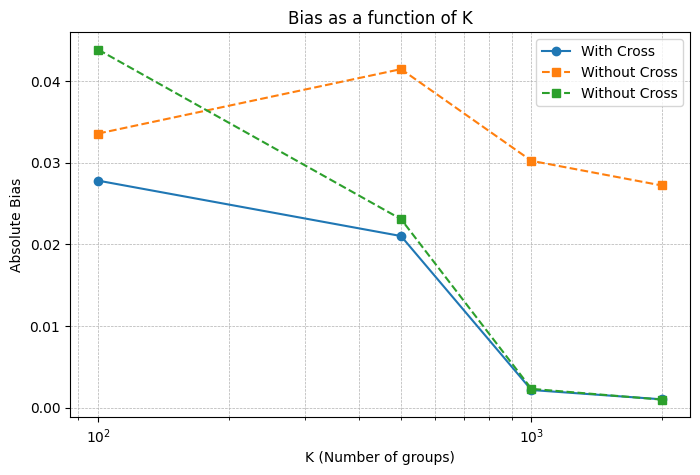

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.solve_dual_riesz import *
from discreteNPIV.utils import *
from discreteNPIV.npiv_2SLS import *
np.random.seed(123)
def evaluate_IPW(K, MC_reps=500, n=30, M=10, step_size=0.2, freq=6, seed = 123):
    h_fun = lambda x:  x
    estimates_IPW = []
    estimates_IPW_no_cross = []
    estimates_truth = []
    estimates_IPW_opt = []
    
    for mc in range(MC_reps):
        print(n, ", ", mc)
        data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[3, 5], seed_exps=seed    , seed_new=seed   )
        #data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[3,3], seed_exps=None  , seed_new=None )
        Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
        h_X = data['h_fun'](X)
        
        knots = generate_basis_functions(K**(-1/3), L=freq)
        X_basis = construct_design_matrix(X, knots) 
        X_new_basis = construct_design_matrix(X_new, knots) 
        
       # ---- NPIV dual (Using CV to choose between npJIVE and 2SLS) ----
        b_hat_opt, _, cv_output = npiv_dual(X_basis, Z, K, X_new_basis, n_splits=10, num_lambda=20, num_gamma=10, verbose=False)
        params_jive, params_2sls, use_npjiv, cross_folds = cv_output
        beta_hat_opt = X_basis @ b_hat_opt


        # ---- npJIVE Fit ----
        b_hat_jive, _ = solve_dual_riesz(
            X_basis, Z, K, X_new_basis, cross_folds=cross_folds,
            lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],num_repeats=10
        )
        beta_hat_jive = X_basis @ b_hat_jive

        
        # ---- 2SLS Fit ----
        b_hat_2sls, _ = solve_dual_riesz_2SLS(
            X_basis, Z, K, X_new_basis, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
        )
        beta_hat_2sls = X_basis @ b_hat_2sls
 
 
        n_total = len(Z)
        group_counts = np.bincount(Z, minlength=K)
        W = group_counts / n_total
        q_hat_0 = compute_group_means(beta_hat_jive, Z, cross_folds, 0, K)
        q_hat_1 = compute_group_means(beta_hat_jive, Z, cross_folds, 1, K)
        T_Y_1 = compute_group_means(Y, Z, cross_folds, 1, K)
        T_Y_0 = compute_group_means(Y, Z, cross_folds, 0, K)
        
        est_IPW = (np.sum(W * q_hat_0 * T_Y_1) + np.sum(W * q_hat_1 * T_Y_0)) / 2
        estimates_IPW.append(est_IPW)

        q_hat_0_opt = compute_group_means(beta_hat_opt, Z, cross_folds, 0, K)
        q_hat_1_opt = compute_group_means(beta_hat_opt, Z, cross_folds, 1, K)
        
        est_IPW_opt = (np.sum(W * q_hat_0_opt * T_Y_1) + np.sum(W * q_hat_1_opt * T_Y_0)) / 2
        estimates_IPW_opt.append(est_IPW_opt)
 
 
        q_hat = compute_group_means(beta_hat_2sls, Z, np.zeros_like(Z), 0, K)
        T_Y = compute_group_means(Y, Z, np.zeros_like(Z), 0, K)
        truth = np.mean(h_fun(X_new))
        est_IPW_no_cross = np.sum(W * q_hat * T_Y) 
        estimates_IPW_no_cross.append(est_IPW_no_cross)
        estimates_truth.append(truth)
        #print(truth, est_IPW, est_IPW_no_cross)
    

    estimates_IPW = np.array(estimates_IPW)
    estimates_IPW_no_cross = np.array(estimates_IPW_no_cross)
    estimates_IPW_opt = np.array(estimates_IPW_opt)
    estimates_truth = np.array(estimates_truth)


    absolute_bias = np.abs(np.mean(np.array(estimates_IPW) - np.array(estimates_truth)))
    absolute_bias_no_cross = np.abs(np.mean(np.array(estimates_IPW_no_cross) - np.array(estimates_truth)))  
    absolute_bias_opt = np.abs(np.mean(np.array(estimates_IPW_opt) - np.array(estimates_truth)))  

    # Compute standard error
    se_with_cross = np.std(estimates_IPW - estimates_truth)  
    se_no_cross = np.std(estimates_IPW_no_cross - estimates_truth)  
    se_opt = np.std(estimates_IPW_opt - estimates_truth)  
    
    # Compute RMSE
    rmse_with_cross = np.sqrt(np.mean((estimates_IPW - estimates_truth) ** 2))
    rmse_no_cross = np.sqrt(np.mean((estimates_IPW_no_cross - estimates_truth) ** 2))
    rmse_opt = np.sqrt(np.mean((estimates_IPW_opt - estimates_truth) ** 2))

    
    return absolute_bias, absolute_bias_no_cross, absolute_bias_opt, se_with_cross, se_no_cross, se_opt, rmse_with_cross, rmse_no_cross, rmse_opt

import matplotlib.pyplot as plt

# Define values of K to test
K_values = [250, 500, 1000, 2000, 3000, 4000, 5000]
bias_values = [evaluate_IPW(K) for K in K_values]  # Assuming compute_bias(K) returns a tuple or list
bias_values_cross = [b[0] for b in bias_values]  # Extract first value (cross)
bias_values_no_cross = [b[1] for b in bias_values]  # Extract second value (no cross)
bias_values_opt = [b[2] for b in bias_values]  # Extract second value (no cross)


# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="With Cross", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Without Cross", markersize=6)
plt.plot(K_values, bias_values_opt, marker='s', linestyle='--', label="Opt", markersize=6)


plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")  # Use log scale for better visualization
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()



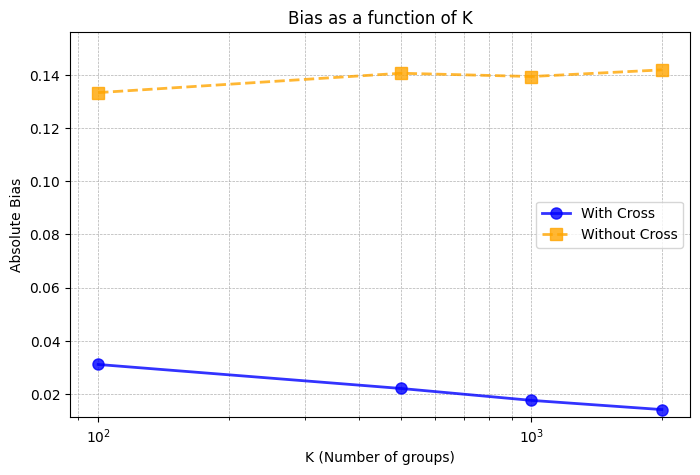

In [13]:
import matplotlib.pyplot as plt

# Define values of K to test
K_values = [100, 500, 1000, 2000]
bias_values = [compute_bias(K) for K in K_values]  # Assuming compute_bias(K) returns a tuple or list
bias_values_cross = [b[0] for b in bias_values]  # Extract first value (cross)
bias_values_no_cross = [b[1] for b in bias_values]  # Extract second value (no cross)
bias_values_opt = [b[2] for b in bias_values]  # Extract second value (no cross)


# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="With Cross", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Without Cross", markersize=6)
plt.plot(K_values, bias_values_opt, marker='s', linestyle='--', label="Without Cross", markersize=6)


plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")  # Use log scale for better visualization
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


## Plug-in estimation

In [290]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.solve_primal_structural import *
from discreteNPIV.utils import *
from discreteNPIV.npiv_2SLS import *
np.random.seed(123)
def evaluate_plugin(K, MC_reps=500, n=100, M=10, step_size=0.2, freq=6, seed = 123):
    h_fun = lambda x: x
    estimates = []
    estimates_opt = []
    estimates_no_cross = []
    estimates_truth = []
    strong_norms = []
    strong_norms_no_cross = []
    L = 3

    
    for mc in range(MC_reps):
        print(mc)
        data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[3, 5], seed_exps=seed   , seed_new=seed   )
        Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
        h_X = data['h_fun'](X)
        
        knots = generate_basis_functions(K**(-1/3), L=L)
        X_basis = construct_design_matrix(X, knots) 
        X_basis_new = construct_design_matrix(X_new, knots) 
        
        # ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
        theta_hat_opt, _, cv_output = npiv_structural(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=False)
        params_jive, params_tsls, use_npjiv, cross_folds = cv_output
        h_hat_opt = X_basis_new @ theta_hat_opt


        # ---- npJIVE Fit ----
        theta_hat_jive, _ = solve_primal_structural(
            X_basis, Z, Y, K, cross_folds=cross_folds,
            lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],num_repeats=10
        )
        h_hat_jive = X_basis_new @ theta_hat_jive

        # ---- 2SLS Fit ----
        theta_hat_tsls, h_fun_init = solve_primal_structural_tsls(
            X_basis, Z, Y, K, lambda_K=params_tsls['lambda'], gamma=params_tsls['gamma']
        )
        h_hat_tsls = X_basis_new @ theta_hat_tsls


        
        est_plugin = np.mean(h_hat_jive)
        estimates.append(est_plugin)
        strong_norm = np.sqrt(np.mean((h_X - X_basis @ theta_hat_jive)**2))
        strong_norms.append(strong_norm)
        
        estimates_opt.append(np.mean(h_hat_opt))
        
        est_plugin_no_cross = np.mean(h_hat_tsls)
        estimates_no_cross.append(est_plugin_no_cross)
        strong_norm_no_cross = np.sqrt(np.mean((h_X - X_basis @ theta_hat_tsls)**2))
        strong_norms_no_cross.append(strong_norm_no_cross)
        
        truth = np.mean(h_fun(X_new))
        estimates_truth.append(truth)

        #print("estimates: ", truth, est_plugin, est_plugin_no_cross, strong_norm, strong_norm_no_cross) 
    
    estimates = np.array(estimates)
    estimates_no_cross = np.array(estimates_no_cross)
    estimates_truth = np.array(estimates_truth)
    estimates_opt = np.array(estimates_opt)
    
    # Compute bias
    absolute_bias = np.abs(np.mean(estimates - estimates_truth))
    absolute_bias_no_cross = np.abs(np.mean(estimates_no_cross - estimates_truth))  
    absolute_bias_opt = np.abs(np.mean(estimates_opt - estimates_truth))  
    
    # Compute standard error
    se_with_cross = np.std(estimates - estimates_truth)  
    se_no_cross = np.std(estimates_no_cross - estimates_truth)  
    
    # Compute RMSE
    rmse_with_cross = np.sqrt(np.mean((estimates - estimates_truth) ** 2))
    rmse_no_cross = np.sqrt(np.mean((estimates_no_cross - estimates_truth) ** 2))

     
    
    return absolute_bias, se_with_cross, rmse_with_cross, absolute_bias_no_cross, se_no_cross, rmse_no_cross, absolute_bias_opt

# Define values of K to test
K_values = [250, 500, 1000, 2000, 3000, 4000, 5000]

bias_results = [evaluate_plugin(K) for K in K_values]  # Assuming compute_bias(K) returns a tuple

bias_values_cross = [b[0] for b in bias_results]  # Bias with cross
se_values_cross = [b[1] for b in bias_results]  # SE with cross
rmse_values_cross = [b[2] for b in bias_results]  # RMSE with cross

bias_values_no_cross = [b[3] for b in bias_results]  # Bias without cross
se_values_no_cross = [b[4] for b in bias_results]  # SE without cross
rmse_values_no_cross = [b[5] for b in bias_results]  # RMSE without cross

bias_values_opt = [b[6] for b in bias_results] 

# Plot the bias results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="Bias (Jive)", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Bias (2SLS)", markersize=6)
plt.plot(K_values, bias_values_opt, marker='s', linestyle='--', label="Bias (CV)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

 


0
1
2
3
4
5


KeyboardInterrupt: 

In [ ]:

# Plot the bias results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="Bias (With Cross)", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Bias (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

# Plot SE results
plt.figure(figsize=(8, 5))
plt.plot(K_values, se_values_cross, marker='o', linestyle='-', label="SE (With Cross)", markersize=6)
plt.plot(K_values, se_values_no_cross, marker='s', linestyle='--', label="SE (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("SE")
plt.title("SE as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Plot RMSE results
plt.figure(figsize=(8, 5))
plt.plot(K_values, rmse_values_cross, marker='o', linestyle='-', label="RMSE (With Cross)", markersize=6)
plt.plot(K_values, rmse_values_no_cross, marker='s', linestyle='--', label="RMSE (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


## DML

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.npiv import *
from discreteNPIV.utils import *
from discreteNPIV.npiv_2SLS import *
 
import pickle  # <-- Add this import for saving results

def remove_extreme_outliers(data, threshold=3):
    """
    Removes extreme outliers from data assuming it follows a Gaussian distribution.
    
    Args:
        data (np.ndarray): Input data array.
        threshold (float): Z-score threshold for outlier detection. Default is 4.
        
    Returns:
        np.ndarray: Filtered data with extreme outliers removed.
    """
    # Calculate mean and standard deviation of the data
    mean = np.mean(data)
    std = np.std(np.quantile(data, [0.01, 0.99]))
    
    # Compute the Z-scores of the data points
    z_scores = (data - mean) / std
    
    # Filter the data based on the Z-score threshold
    keep = np.abs(z_scores) <= threshold
    
    # Print results
    print(f"Original data size: {len(data)}")
    print(f"Filtered data size: {sum(keep)}")
    
    return keep

 


def perform_simulation(K, MC_reps=200, n=50, M=10, step_size=0.3, seed=123, seed_new = 123):
    h_fun = lambda x: x
    results = {'dml_jive': [], 'plugin_jive': [], 'ipw_jive': [], 'ci_jive': [],
               'dml_tsls': [], 'plugin_tsls': [], 'ipw_tsls': [], 'ci_tsls': [],
               'dml_jsingle': [], 'ci_single': [], 'ci_jve_single_oracle': [],
               'ci_jive_oracle': [],
               'truth': []}
    L = 2
    N = n * K

    for mc in range(MC_reps):
        print(f'MC iteration: {mc}, K: {K}, n: {n}')
        data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1,
                             range_ab=(1,3), ab_new=[3, 5], seed_exps=seed, seed_new=seed_new)
        data_train =  generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1,
                                range_ab=(1,3), ab_new=[3, 5], seed_exps=seed, seed_new=seed_new)

        Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
        h_X = data['h_fun'](X)
 

        knots = generate_basis_functions(N**(-1/3), L=L)
        X_basis = construct_design_matrix(X, knots)
        print("p: ", X_basis.shape[1])
        X_basis_new = construct_design_matrix(X_new, knots)
        X_basis_train = construct_design_matrix(data_train['X'], knots)

        dtrain = {"X": X_basis_train, "Z": data_train['Z'], "Y": data_train['Y']}

        output_jive = npiv_dml(X_basis, Z, Y, X_basis_new, dtrain=dtrain, cv_n_splits=5,
                               num_lambda=20, num_gamma=10, num_repeats=5, adaptive = False, verbose=False)

        estimate_dml_jive = output_jive['estimate']
        estimate_plugin_jive = output_jive['estimate_plugin']
        estimate_IPW_jive = output_jive['estimate_IPW']
        ci_lower_jive = output_jive['ci_lower']
        ci_upper_jive = output_jive['ci_upper']

        # Store JIVE results
        results['dml_jive'].append(estimate_dml_jive)
        results['plugin_jive'].append(estimate_plugin_jive)
        results['ipw_jive'].append(estimate_IPW_jive)
        results['ci_jive'].append((ci_lower_jive, ci_upper_jive))

        


        # Store single jive results
        output_jive_single = output_jive['output_jive_single']
        estimate_dml_jsingle = output_jive_single['estimate']
        ci_lower_single = output_jive_single['ci_lower']
        ci_upper_single = output_jive_single['ci_upper']

        results['dml_jsingle'].append(estimate_dml_jsingle)
        results['ci_single'].append((ci_lower_single, ci_upper_single))
        
        # store 2SLS results
        output_tsls = output_jive['output_2sls']
        estimate_dml_tsls = output_tsls['estimate']
        estimate_plugin_tsls = output_tsls['estimate_plugin']
        estimate_IPW_tsls = output_tsls['estimate_IPW']
        ci_lower_tsls = output_tsls['ci_lower']
        ci_upper_tsls = output_tsls['ci_upper']

        results['dml_tsls'].append(estimate_dml_tsls)
        results['plugin_tsls'].append(estimate_plugin_tsls)
        results['ipw_tsls'].append(estimate_IPW_tsls)
        results['ci_tsls'].append((ci_lower_tsls, ci_upper_tsls))

        # Store the true value
        results['truth'].append(np.mean(X_new))

    keep_jive = remove_extreme_outliers(results['dml_jive'])
    keep_single = remove_extreme_outliers(results['dml_jsingle'])
    se_jive_oracle = np.std(np.array(results['dml_jive'])[keep_jive])
    results['ci_jive_oracle'] = (results['dml_jive'] - 1.96 * se_jive_oracle, results['dml_jive'] + 1.96 * se_jive_oracle)
    se_single_oracle = np.std(np.array(results['dml_jsingle'])[keep_single])
    results['ci_jve_single_oracle'] = (results['dml_jsingle'] - 1.96 * se_single_oracle, results['dml_jsingle'] + 1.96 * se_single_oracle)

    
    return results

 

 
# Define values of n and K to test

K_values = [500, 1000, 1500, 2000]
all_results = {K : perform_simulation(K, n=60, MC_reps = 200) for K in K_values}
# Perform simulations for all combinations of n and K
if False:
    n_values = [30, 60, 120, 240]
    K_values = [500, 1000, 2000, 3000, 4000]
    all_results = {}
    for n in n_values:
        for K in K_values:
            results = perform_simulation(K, n=n, MC_reps = 200)
            all_results[(n, K)] = results
        
            # Save results to file
            filename = f"results_n{n}_K{K}.pkl"
            with open(filename, 'wb') as f:
                pickle.dump(results, f)
            print(f"Saved results to {filename}")
 

MC iteration: 0, K: 500, n: 60
p:  33
time to tune primal:  0.06139707565307617 , time to cv split:  0.14163613319396973
time to tune dual:  0.15979599952697754 , time to cv split:  0.27832603454589844
-0.006070620832212253 -0.006070620832212253
MC iteration: 1, K: 500, n: 60
p:  33
time to tune primal:  0.05135393142700195 , time to cv split:  0.23106908798217773
time to tune dual:  0.16731476783752441 , time to cv split:  0.24996519088745117
-0.02309359138838047 -0.023093591388380467
MC iteration: 2, K: 500, n: 60
p:  33
time to tune primal:  0.041433095932006836 , time to cv split:  0.17465996742248535
time to tune dual:  0.1666240692138672 , time to cv split:  0.2769458293914795
-0.04301159661336364 -0.04301159661336363
MC iteration: 3, K: 500, n: 60
p:  33
time to tune primal:  0.07656502723693848 , time to cv split:  0.21529603004455566
time to tune dual:  0.16423916816711426 , time to cv split:  0.2715938091278076
0.0022284668350364295 0.0022284668350364316
MC iteration: 4, K: 5

In [123]:
import pickle
ab_new=[2,3 ]  
n = 30
K = 1000
 
def load_results(K, n = 30, ab_new=[2,3 ]):
    filename = f"results_n{n}_K{K}_18_ab{ab_new[0]}_{ab_new[1]}_123.pkl"
    with open(filename, 'rb') as file:
        results = pickle.load(file)
    summary = summarize_results(results)
    return summary

 

Original data size: 1000
Filtered data size: 992
992 992
Original data size: 1000
Filtered data size: 997
997 997
Original data size: 1000
Filtered data size: 990
990 990
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 999
999 999
Original data size: 1000
Filtered data size: 988
988 988


{'dml_jive': {'Absolute Bias': np.float64(0.0005355887795254275),
  'SE': np.float64(0.008235796104640834),
  'RMSE': np.float64(0.008253192886269575),
  'Coverage': np.float64(0.9536290322580645)},
 'plugin_jive': {'Absolute Bias': np.float64(0.001072942204042119),
  'SE': np.float64(0.00802445388111711),
  'RMSE': np.float64(0.008095867159445628),
  'Coverage': nan},
 'ipw_jive': {'Absolute Bias': np.float64(0.014478964132422861),
  'SE': np.float64(0.02190994258831509),
  'RMSE': np.float64(0.02626187324947044),
  'Coverage': nan},
 'dml_tsls': {'Absolute Bias': np.float64(0.020983141753310886),
  'SE': np.float64(0.006494896724246103),
  'RMSE': np.float64(0.021965334536449957),
  'Coverage': np.float64(0.107)},
 'plugin_tsls': {'Absolute Bias': np.float64(0.011878605396168676),
  'SE': np.float64(0.00683081959853444),
  'RMSE': np.float64(0.013702604224949717),
  'Coverage': nan},
 'ipw_tsls': {'Absolute Bias': np.float64(0.008011164905041303),
  'SE': np.float64(0.014888883306562

Original data size: 1000
Filtered data size: 994
994 994
Original data size: 1000
Filtered data size: 997
997 997
Original data size: 1000
Filtered data size: 993
993 993
Original data size: 1000
Filtered data size: 999
999 999
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 999
999 999
Original data size: 1000
Filtered data size: 995
995 995
Original data size: 1000
Filtered data size: 999
999 999
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 986
986 986
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 995
995 995
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 1000
1000 1000
Original data size: 1000
Filtered data size: 986
986 986
Original d

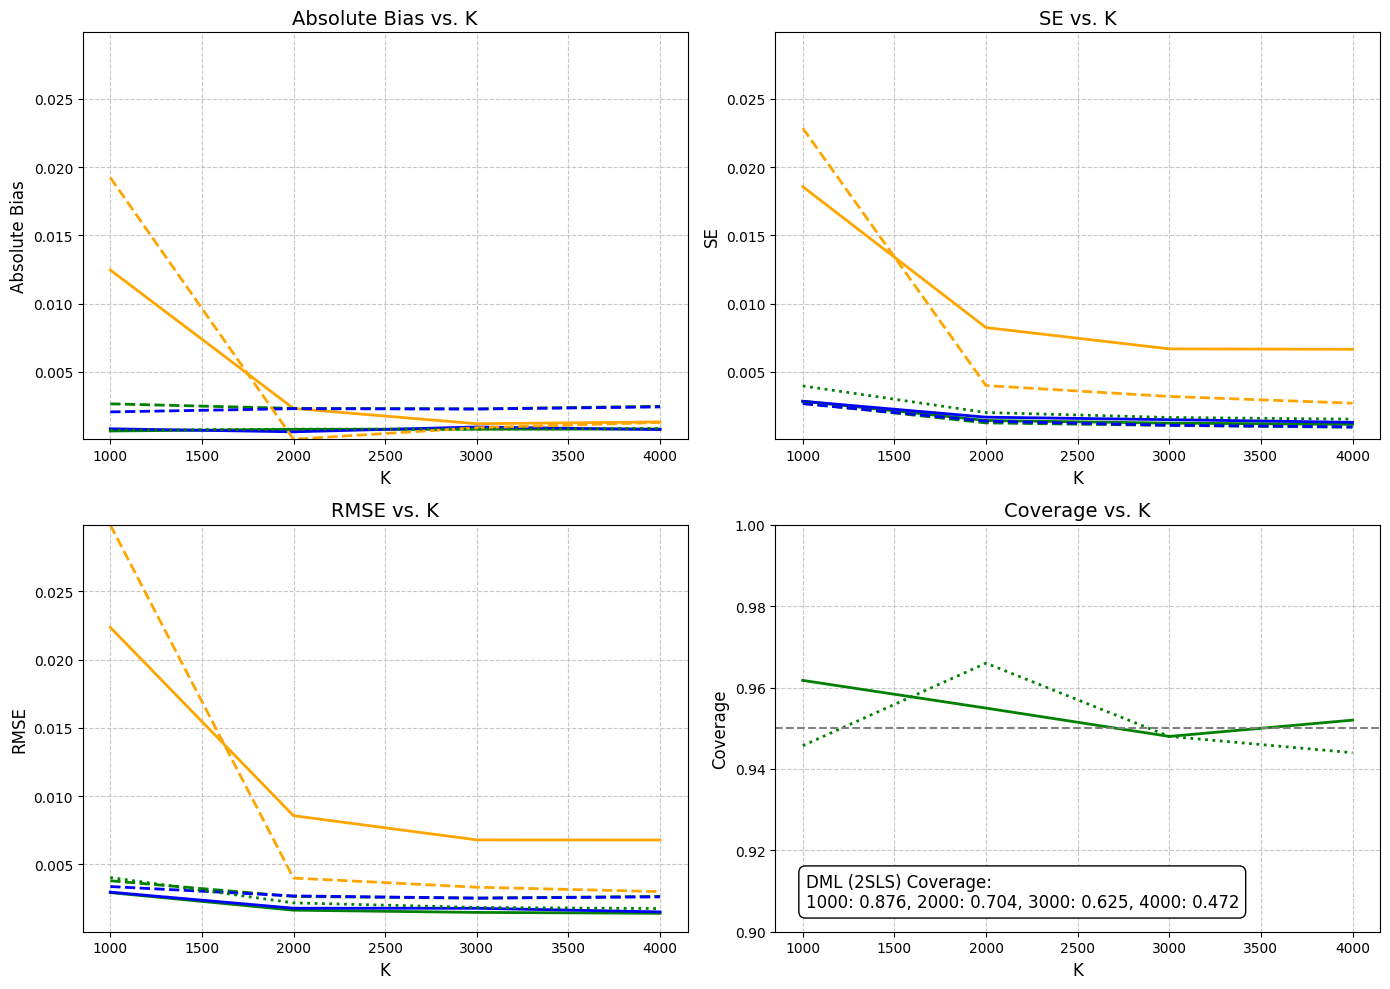

In [179]:
import matplotlib.pyplot as plt
import numpy as np
 
def load_results(K, n = 30, ab_new=[2,3 ]):
    filename = f"results_n{n}_K{K}_18_ab{ab_new[0]}_{ab_new[1]}_123.pkl"
    with open(filename, 'rb') as file:
        results = pickle.load(file)
    summary = summarize_results(results)
    return summary



def remove_extreme_outliers(data, threshold=4):
    """
    Removes extreme outliers from data assuming it follows a Gaussian distribution.
    
    Args:
        data (np.ndarray): Input data array.
        threshold (float): Z-score threshold for outlier detection. Default is 4.
        
    Returns:
        np.ndarray: Filtered data with extreme outliers removed.
    """
    # Calculate mean and standard deviation of the data
    mean = np.median(data)
    percentiles = np.quantile(data, [0.1, 0.9])
    std = (percentiles[1] - percentiles[0]) / 2.564
    
    # Compute the Z-scores of the data points
    z_scores = (data - mean) / std
    
    # Filter the data based on the Z-score threshold
    keep = np.abs(z_scores) <= threshold
    
    # Print results
    print(f"Original data size: {len(data)}")
    print(f"Filtered data size: {sum(keep)}")
    
    return keep

def summarize_results(results):
    def compute_metrics(estimates, truths, cis=None):
        estimates = np.array(estimates)
        truths = np.array(truths)
        
        keep = remove_extreme_outliers(estimates)
        estimates = estimates[keep]
        truths = truths[keep]
        
        absolute_bias = np.abs(np.mean(estimates - truths))
        se = np.std(estimates - truths)
        rmse = np.sqrt(np.mean((estimates - truths) ** 2))
        print(len(estimates), len(truths))
        if cis is not None:
            cis = [item for item, keep_item in zip(cis, keep) if keep_item]
            coverage = np.mean([(ci[0] <= truth <= ci[1]) for ci, truth in zip(cis, truths)])
        else:
            coverage = np.nan
        return absolute_bias, se, rmse, coverage

    summaries = {}
    for method in ['dml_jive', 'plugin_jive', 'ipw_jive', 'dml_tsls', 'plugin_tsls', 'ipw_tsls', 'dml_jsingle']:
        try:
            estimates = results[method]
            if 'plugin' in method or 'ipw' in method:
                absolute_bias, se, rmse, coverage = compute_metrics(estimates, results['truth'])
            else:  # Only compute coverage for DML methods
                if 'jive' in method:
                    ci_key = 'ci_jive'
                elif 'single' in method:
                    ci_key = 'ci_single'
                else:
                    ci_key = 'ci_tsls'

                absolute_bias, se, rmse, coverage = compute_metrics(estimates, results['truth'], results.get(ci_key))

            summaries[method] = {
                'Absolute Bias': absolute_bias,
                'SE': se,
                'RMSE': rmse,
                'Coverage': coverage
            }

        except KeyError as e:
            print(f"KeyError for method '{method}': {e}")

    return summaries


def plot_results(n, ab_new, K_values):

    results = {K: load_results(K, n = n, ab_new = ab_new) for K in K_values}
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics = ['Absolute Bias', 'SE', 'RMSE', 'Coverage']

    method_mapping = {
        'dml_jive': 'DML (JIVE)',
        'plugin_jive': 'Plug-in (JIVE)',
        'ipw_jive': 'IPW (JIVE)',
        'dml_tsls': 'DML (2SLS)',
        'plugin_tsls': 'Plug-in (2SLS)',
        'ipw_tsls': 'IPW (2SLS)',
        'dml_jsingle': 'DML (JIVE 1-fold)'
    }

    colors = {'dml': 'green', 'plugin': 'blue', 'ipw': 'orange'}
    line_styles = {'jive': '-', 'tsls': 'dashed', 'jsingle': 'dotted'}
    methods = ['dml_jive', 'plugin_jive', 'ipw_jive', 'dml_tsls', 'plugin_tsls', 'ipw_tsls', 'dml_jsingle']

    all_handles = []
    all_labels = []

    tsls_coverages = {'dml_tsls': [], 'dml_jsingle': [], 'dml_jive': []}

    # Find global min and max for Absolute Bias, SE, and RMSE
    metric_values = {metric: [] for metric in ['Absolute Bias', 'SE', 'RMSE']}
    for metric in ['Absolute Bias', 'SE', 'RMSE']:
        for method in methods:
            for K in K_values:
                value = results[K][method].get(metric, np.nan)
                if not np.isnan(value):
                    metric_values[metric].append(value)
    
    # Find global limits
    global_min = min(min(metric_values['Absolute Bias']), min(metric_values['SE']), min(metric_values['RMSE']))
    global_max = max(max(metric_values['Absolute Bias']), max(metric_values['SE']), max(metric_values['RMSE']))

    for i, metric in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        for method in methods:
            if metric == 'Coverage' and method == 'dml_tsls':
                coverage_values = [results[K][method]['Coverage'] for K in K_values]
                coverage_str = ", ".join([f"{K}: {coverage:.3f}" for K, coverage in zip(K_values, coverage_values)])
                textstr = f"DML (2SLS) Coverage:\n{coverage_str}"
                ax.text(0.05, 0.05, textstr, transform=ax.transAxes, fontsize=12,
                    verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black'))
    
    
    
                continue  
            try:
                method_type, model_type = method.split('_')[:2]
                label = method_mapping[method]
                color = colors[method_type]
                linestyle = line_styles[model_type]

                values = [results[K][method].get(metric, np.nan) for K in K_values]
                line, = ax.plot(K_values, values, label=label, lw=2, color=color, linestyle=linestyle)

                if i == 0:
                    all_handles.append(line)
                    all_labels.append(label)

            except KeyError as e:
                print(f"KeyError when plotting {method}: {e}")

            
        ax.set_xlabel('K', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.set_title(f'{metric} vs. K', fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.7)

        if metric == 'Coverage':
            ax.axhline(0.95, color='grey', linestyle='--', linewidth=1.5)
            ax.set_ylim(0.9, 1)
        elif metric in ['Absolute Bias', 'SE', 'RMSE']:
            ax.set_ylim(global_min, global_max)


    desired_order = ['dml_jive', 'dml_tsls', 'dml_jsingle', 'plugin_jive', 'plugin_tsls', 'ipw_jive', 'ipw_tsls']
    sorted_handles_labels = sorted(zip(all_handles, all_labels), key=lambda x: desired_order.index(next(key for key, value in method_mapping.items() if value == x[1])))

    sorted_handles, sorted_labels = zip(*sorted_handles_labels)

   
    #fig.legend(sorted_handles, sorted_labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), fontsize=12, title='Methods', title_fontsize=12, ncol=3)


    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    plt.savefig(f'plot_results_{n}_K{K}_18_ab{ab_new[0]}_{ab_new[1]}_123.pdf', format='pdf', bbox_inches='tight')

    plt.show()


K_values = [1000, 2000, 3000, 4000]
n = 300
ab_new = [2, 3.5]
plot_results(n, ab_new, K_values)


In [26]:
summaries

{500: {'dml_jive': {'Absolute Bias': np.float64(0.006170561025507568),
   'SE': np.float64(0.012390224714536756),
   'RMSE': np.float64(0.013841730088620803),
   'Coverage': np.float64(0.85)},
  'plugin_jive': {'Absolute Bias': np.float64(0.010295533748961057),
   'SE': np.float64(0.01521878905301497),
   'RMSE': np.float64(0.018374154549697364),
   'Coverage': nan},
  'ipw_jive': {'Absolute Bias': np.float64(0.020663170102311678),
   'SE': np.float64(0.06196466340924626),
   'RMSE': np.float64(0.0653191098385323),
   'Coverage': nan},
  'dml_tsls': {'Absolute Bias': np.float64(0.020801843429900897),
   'SE': np.float64(0.007461271387508513),
   'RMSE': np.float64(0.022099485532477096),
   'Coverage': np.float64(0.19)},
  'plugin_tsls': {'Absolute Bias': np.float64(0.008492449827392279),
   'SE': np.float64(0.01229845071926493),
   'RMSE': np.float64(0.01494568814625018),
   'Coverage': nan},
  'ipw_tsls': {'Absolute Bias': np.float64(0.0058539735639480004),
   'SE': np.float64(0.04406